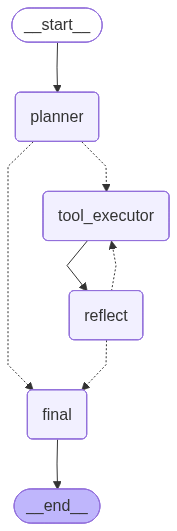

In [3]:
from dotenv import load_dotenv
from PIL import Image
from tools.models_utils import score_aesthetic
from tools.exif_tool import fetch_exif
from tools.captioning_tool import caption_image
from rag.retriever_fetch_tool import retrieve_photography_tips
from agent.agent_state import ToolCalls
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from agent.graph import build_graph
from langchain_core.messages import HumanMessage
from IPython.display import Image, display

load_dotenv()

# pil_img = Image.open("data\DSCF0677.JPG").convert("RGB")
# aesthetic_scorer = score_aesthetic_tool
# probs, mean_score = aesthetic_scorer.invoke({"pil_img": pil_img})
# print(probs)
# print(mean_score)

retrieve_photography_tips_tool = retrieve_photography_tips
score_aesthetic_tool = score_aesthetic
fetch_exif_tool = fetch_exif
captioning_tool = caption_image
tools = [retrieve_photography_tips_tool, score_aesthetic_tool, fetch_exif_tool, captioning_tool]

response_model = init_chat_model("gpt-5-nano", temperature=0)

tool_decider_model = create_agent(
    model="gpt-5-nano",
    tools=tools,
    response_format=ToolCalls
)

graph = build_graph(tool_decider_model, response_model, response_model)
display(Image(graph.get_graph().draw_mermaid_png()))